# Logistic Regression from Scratch: Gradient Descent on the Titanic Dataset

This notebook reimplements logistic regression example from Part 1, but instead of calling `LogisticRegression().fit()`,
we derive and implement **gradient descent** by hand.

We will:
1. Load and preprocess the Titanic dataset.
2. Review the mathematical foundations of logistic regression.
3. Implement gradient descent to learn the model weights.
4. Compare our results against scikit-learn.

In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 1. Data Loading and Preprocessing

In [40]:
data = pd.read_csv("../data/titanic.csv")
data.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [41]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


## 2. Feature Standardization

Gradient descent converges much faster when features are on a similar scale.
We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.

In [42]:
# TODO: Implement feature standardization.
# x_standardized = (x - mean) / std
mean_train = X_train.mean()
std_train = X_train.std(ddof=0)

X_train_s = (X_train - mean_train) / std_train
X_test_s = (X_test - mean_train) / std_train

print("Mean of standardized training features:")
print(X_train_s.mean())

print("\nStandard deviation of standardized training features:")
print(X_train_s.std(ddof=0))

Mean of standardized training features:
sex           -1.077339e-16
age           -2.881256e-17
family_size    3.257072e-17
fare           7.015232e-17
1st_class      1.077339e-16
2nd_class      1.064812e-16
3rd_class      2.505440e-18
dtype: float64

Standard deviation of standardized training features:
sex            1.0
age            1.0
family_size    1.0
fare           1.0
1st_class      1.0
2nd_class      1.0
3rd_class      1.0
dtype: float64


The standardized mean should be close to 0, and the standardized std should be close to 1.

## 3. Mathematical Background

### 3.1 The Logistic (Sigmoid) Function

In logistic regression we model the probability that a sample belongs to the
positive class ($y = 1$) using the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where the linear combination (logit) is:

$$
z = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{d} w_j x_j + b
$$

Here $\mathbf{w} \in \mathbb{R}^d$ is the weight vector, $b \in \mathbb{R}$ is
the bias (intercept), and $d$ is the number of features.

The sigmoid function maps any real-valued input to a value between 0 and 1. 
We will use it to transform the model’s raw output (which can be any real number) into a probability. 
Large positive numbers are mapped close to 1, large negative numbers are mapped close to 0. 
This makes it suitable for binary classification.

The predicted probability is therefore:

$$
\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

The model computes a weighted sum of the input features and adds a bias term. 
This linear combination represents how strongly the input features support one class over the other. 
The sigmoid function then converts this value into a probability.

For example, a value of 0.8 means that the model estimated an 80% chance that the input belongs to the positive class.

### 3.2 Binary Cross-Entropy Loss

We measure how well the model fits the training data using the
**binary cross-entropy** (log loss), averaged over $n$ samples:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
  y^{(i)} \ln\!\big(\hat{y}^{(i)}\big)
  + \big(1 - y^{(i)}\big) \ln\!\big(1 - \hat{y}^{(i)}\big)
\right]
$$

This loss is **convex** in $\mathbf{w}$ and $b$, so gradient descent is
guaranteed to find the global minimum.

The loss function measures how well the model predictions (the probabilities) match the true labels.  
Binary cross-entropy penalizes confident but incorrect predictions more heavily than uncertain ones.
If the model predicts a probability close to the true label, the loss is small, otherwise the loss increases rapidly.

### 3.3 Gradient Derivation

To compute how the loss changes with respect to the model parameters, gradients tell us in which direction we need to adjust the parameters to reduce the loss.

If the predictions are too high, this will lead to gradients with positive values. 
If predictions are too low, this will lead to gradients with negative values. 
The magnitude depends on how large the error is and the value of the input features.

To minimize $\mathcal{L}$ we need the partial derivatives with respect to each weight $w_j$ and the bias $b$.

Using the chain rule and the identity
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the gradients simplify to:

$$
\frac{\partial \mathcal{L}}{\partial w_j}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)\, x_j^{(i)}
$$

$$
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)
$$

Or in compact vector notation, with
$\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$:

$$
\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y})
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \mathbf{1}^\top (\hat{\mathbf{y}} - \mathbf{y})
$$

### 3.4 Gradient Descent Update Rule

We iteratively update the parameters using a learning rate $\alpha$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} \mathcal{L}
$$

$$
b \leftarrow b - \alpha\, \frac{\partial \mathcal{L}}{\partial b}
$$

At each step, the model updates the parameters slightly to reduce loss. Over many iterations, this leads to a set of parameters that fit the data well.

The learning rate $\alpha$ determines how large the update step is when adjusting the model parameters during training. 
Small learning rates (e.g. $\alpha = 0.001$) are slow but stable, whereas large learning rates ($\alpha = 0.1$) are fast, but may cause instabilities and training may fail completely.

We repeat until convergence (i.e., until the loss changes by less than a pre-defined tolerance $\varepsilon$), or if a maximum number of iterations is reached.

## 4. Implementation

Now it's time to implement the algorithm.
You need to account for numerical stability to ensure that the algorithm's returned results are sound.

In [43]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """A numerically stable sigmoid function."""
    # 1 / 1 + e^(-z)
    z = np.asarray(z)
    z = np.clip(z, -500, 500) # limit the numbers within -500 to 500
    return 1 / (1 + np.exp(-z))

In [44]:
# test sigmoid
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))
print(sigmoid(0))
print(sigmoid(100))
print(sigmoid(-100))

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]
0.5
1.0
3.7200759760208356e-44


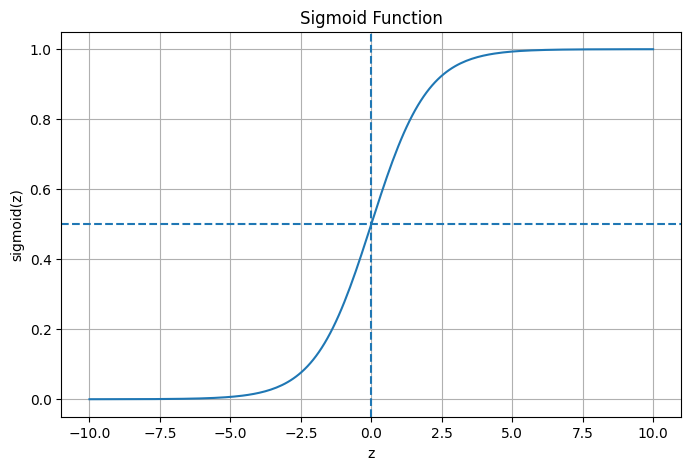

In [45]:
# sigmoid curve
import matplotlib.pyplot as plt

z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

In [46]:
def binary_cross_entropy(y: np.ndarray, y_hat: np.ndarray) -> float:
    """Compute the mean binary cross-entropy loss.

    Take care in your implementation to ensure that the cross entropy is always positive,
    and that it stays stable for very small probabilities (y_hat \approx 0).
    """
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)
    
    #avoid log(0)
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1-eps)
    
    loss = -np.mean(y * np.log(y_hat) + (1 -  y) * np.log(1-y_hat))
    return loss

In [47]:
# testing binary cross entropy
# when true answer is 1, test the loss
y_true = np.array([1, 1, 1])

pred_very_good = np.array([0.99, 0.95, 0.90])
pred_uncertain = np.array([0.55, 0.50, 0.60])
pred_bad = np.array([0.01, 0.10, 0.20])

print(binary_cross_entropy(y_true, pred_very_good))
print(binary_cross_entropy(y_true, pred_uncertain))
print(binary_cross_entropy(y_true, pred_bad))

0.05556804863295944
0.6006032683605188
2.8390643971387455


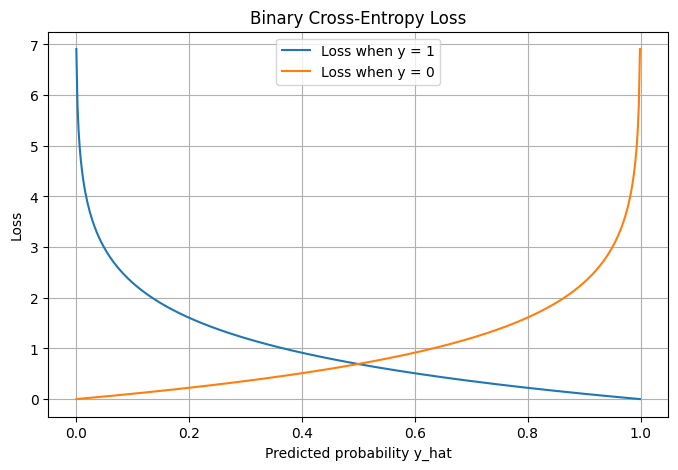

In [48]:
# function loss curve
p = np.linspace(0.001, 0.999, 500)

loss_when_y_is_1 = -np.log(p)
loss_when_y_is_0 = -np.log(1 - p)

plt.figure(figsize=(8, 5))
plt.plot(p, loss_when_y_is_1, label="Loss when y = 1")
plt.plot(p, loss_when_y_is_0, label="Loss when y = 0")
plt.xlabel("Predicted probability y_hat")
plt.ylabel("Loss")
plt.title("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
def logistic_regression_gd(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    max_iter: int = 1000,
    tol: float = 1e-6,
) -> tuple[np.ndarray, float, list[float]]:
    """Train logistic regression via gradient descent.

    Returns (weights, bias, loss_history).
    """
    # steps: for every feature sample - calculate z - get probability - calculate loss - find dw & db - update w & b untill loss changes no more
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    loss_hist = []

    for iter in range(max_iter):
        z = X @ w + b #dot
        y_hat = sigmoid(z)
        
        loss = binary_cross_entropy(y, y_hat)
        loss_hist.append(loss)

        #calculate dw
        dw = (X.T @ (y_hat - y)) / n_samples
        # dw = np.zeros(n_features)
        # for j in range(n_features):
        #     total = 0.0
    
        #     for i in range(n_samples):
        #         total += X[i, j] * error[i]
            
        #     dw[j] = total / n_samples

        db = np.mean(y_hat - y)

        for j in range(n_features):
            w[j] -= lr * dw[j]
        
        b -= lr * db

        #break if loss change too little
        if iter > 0 and abs(loss_hist[-1] - loss_hist[-2]) < tol:
            break
        
    return w, b, loss_hist

## 5. Training

In [50]:
# convert python array to NumPy array
X_train_np = X_train_s.to_numpy()
X_test_np = X_test_s.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [59]:
# Train our model on the standardized features
w, b, loss_history = logistic_regression_gd(X_train_np, y_train_np, lr=0.1, max_iter=1000, tol=1e-8)

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Iterations: {len(loss_history)}")
print(f"\nLearned weights:")
for name, weight in zip(FEATURES, w):
    print(f"  {name:>30s}: {weight:+.4f}")
print(f"  {'bias':>30s}: {b:+.4f}")

Final loss: 0.425739
Iterations: 867

Learned weights:
                             sex: -1.4043
                             age: -0.5256
                     family_size: -0.5271
                            fare: +0.2450
                       1st_class: +0.4793
                       2nd_class: +0.1120
                       3rd_class: -0.5028
                            bias: -0.6383


### Loss Curve

A decreasing loss curve confirms that gradient descent is working correctly.

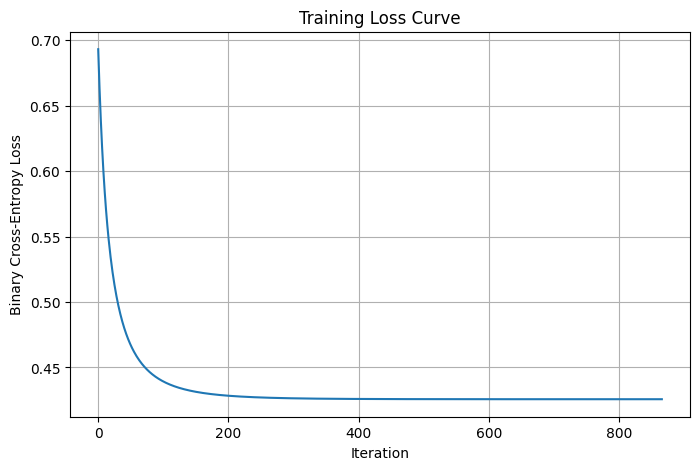

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## 6. Evaluation

We classify a sample as positive ($\hat{y} = 1$) when $\sigma(z) \geq 0.5$,
which is equivalent to $z \geq 0$.

In [53]:
def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """Predict class labels (0 or 1)."""
    X = np.asarray(X)
    z = X @ w + b
    y_hat = sigmoid(z)

    # round to 0/1 with threshold 0.5
    y_pred = (y_hat >= 0.5).astype(int)
    return y_pred

# Evaluate on train and test sets
y_pred_train = predict(X_train_np, w, b)
y_pred_test = predict(X_test_np, w, b)

print("Train predictions shape:", y_pred_train.shape)
print("Test predictions shape:", y_pred_test.shape)

print("First 10 train predictions:", y_pred_train[:10])
print("First 10 test predictions:", y_pred_test[:10])

Train predictions shape: (709,)
Test predictions shape: (178,)
First 10 train predictions: [0 0 0 1 1 0 1 0 0 0]
First 10 test predictions: [0 0 0 0 0 1 0 0 1 1]


In [54]:
def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute classification accuracy."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    return np.mean(y_true == y_pred)


print(f"Our model — Train accuracy: {accuracy(y_train_np, y_pred_train):.4f}")
print(f"Our model — Test accuracy:  {accuracy(y_test_np, y_pred_test):.4f}")

Our model — Train accuracy: 0.8209
Our model — Test accuracy:  0.7416


## 7. Comparison with scikit-learn

We train the same model using scikit-learn's `LogisticRegression` (with the
same standardized data) to verify that our gradient descent implementation
arrives at comparable accuracy and weights.

In [55]:
# scikit-learn logistic regression (no regularization, to match our implementation)
sk_model = LogisticRegression(max_iter=200, random_state=42, C=np.inf)
sk_model.fit(X_train_np, y_train_np)

sk_accuracy = sk_model.score(X_test_np, y_test_np)
our_accuracy = accuracy(y_test_np, y_pred_test)

print(f"scikit-learn test accuracy: {sk_accuracy:.4f}")
print(f"Our GD test accuracy:      {our_accuracy:.4f}")
print()
 
# Compare learned weights
print(f"{'Feature':>30s} | {'Ours':>8s} | {'sklearn':>8s}")
print("-" * 55)
for name, w_ours, w_sk in zip(FEATURES, w, sk_model.coef_[0]):
    print(f"{name:>30s} | {w_ours:+8.4f} | {w_sk:+8.4f}")
print(f"{'bias':>30s} | {b:+8.4f} | {sk_model.intercept_[0]:+8.4f}")

scikit-learn test accuracy: 0.7528
Our GD test accuracy:      0.7416

                       Feature |     Ours |  sklearn
-------------------------------------------------------
                           sex |  -1.4043 |  -1.4067
                           age |  -0.5256 |  -0.5284
                   family_size |  -0.5271 |  -0.5307
                          fare |  +0.2450 |  +0.2455
                     1st_class |  +0.4793 |  +0.4802
                     2nd_class |  +0.1120 |  +0.1120
                     3rd_class |  -0.5028 |  -0.5036
                          bias |  -0.6383 |  -0.6390


/Users/XiaojunHuang/Desktop/MLops/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


### Observasion
The test accuracy of my model is slightly lower than the scikit-learn model, but the learned weights and bias are almost identical. This indicates that the gradient descent implementation is correct and converges to nearly the same decision function. 

The small difference in accuracy may be caused by differences in optimization algorithms, stopping criteria, and numerical precision. Since accuracy depends on a fixed threshold of 0.5, even very small differences in predicted probabilities can lead to different class predictions for samples near the decision boundary.

Overall, the comparison shows that my implementation performs similarly to scikit-learn's LogisticRegression..

## Summary

We implemented logistic regression from scratch using gradient descent and
verified it against scikit-learn. Key takeaways:

- The **sigmoid function** maps any real number to a probability in $(0, 1)$.
- The **binary cross-entropy loss** is convex, so gradient descent finds the
  global optimum.
- **Feature standardization** is critical for gradient descent to converge
  efficiently — without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned.
- Our hand-rolled implementation reaches the same accuracy and learns
  nearly identical weights as scikit-learn's optimized solver.